# Bank term deposit subscription prediction

### Task

In this project, we address a binary classification problem in the banking domain.

The objective is to build a model that predicts whether a client will subscribe to a term deposit based on client information, previous marketing interactions, and macroeconomic indicators.

Such problems are common in practice, where companies aim to predict customer behavior, such as product purchase, subscription, or service usage.


### Dataset

The dataset is based on direct marketing campaigns (phone calls) conducted by a Portuguese banking institution. In many cases, multiple contacts were required to determine whether a client would subscribe to the product.

The classification target is:
- `y`: whether the client subscribed to a term deposit (yes/no)

The dataset contains 41,188 observations and 20 input features, including:

#### bank client data:

1. **age** – age (numeric).  
2. **job** – type of job (categorical: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – marital status (categorical: `divorced`, `married`, `single`, `unknown`; note: `divorced` means divorced or widowed).  
4. **education** – education (categorical: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – has credit in default? (categorical: `no`, `yes`, `unknown`).  
6. **housing** – has housing loan? (categorical: `no`, `yes`, `unknown`).  
7. **loan** – has personal loan? (categorical: `no`, `yes`, `unknown`).  

#### Related with the last contact of the current campaign

8. **contact** – contact communication type (categorical: `cellular`, `telephone`).  
9. **month** – last contact month of year (categorical: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – last contact day of the week (categorical: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.  

#### Other attributes

12. **campaign** – number of contacts performed during this campaign and for this client (numeric, includes last contact).  
13. **pdays** – number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted).  
14. **previous** – number of contacts performed before this campaign and for this client (numeric).  
15. **poutcome** – outcome of the previous marketing campaign (categorical: `failure`, `nonexistent`, `success`).  

#### Social and economic context attributes

16. **emp.var.rate** – employment variation rate - quarterly indicator (numeric).  
17. **cons.price.idx** – consumer price index - monthly indicator (numeric).  
18. **cons.conf.idx** – consumer confidence index - monthly indicator (numeric).  
19. **euribor3m** – euribor 3 month rate - daily indicator (numeric).  
20. **nr.employed** – number of employees - quarterly indicator (numeric).  

#### Target variable

21. **y** – has the client subscribed a term deposit? (binary: `yes`, `no`).  

Important note:  
The variable `duration` has a strong influence on the target but is not available before the call is completed. Therefore, it is excluded from the final model to ensure a realistic prediction setup.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [3]:
raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bank-additional-full.csv', delimiter=';')

## EDA

In [4]:
raw_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [5]:
raw_df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
raw_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
raw_df['y'].value_counts(normalize=True)*100

,proportion
y,
no,88.734583
yes,11.265417


**Conclusions**

- No missing values were found in the dataset. However, some categorical variables contain the category "unknown", which will be preserved as a separate category, as it may carry useful information

- The target variable y is imbalanced: approximately 11% of observations belong to the "yes" class, while 89% belong to "no". This may cause models to be biased toward the majority class

- To address class imbalance, resampling techniques will be considered for models such as Logistic Regression, kNN, and Decision Tree

- For model evaluation, metrics that are robust to class imbalance will be used, including ROC-AUC and F1-score

### Hypothesis

- Older clients may be more likely to subscribe to term deposits due to higher financial stability and savings

- Clients with stable income (e.g., management, admin.) are more likely to subscribe to term deposits compared to unemployed or students

- Clients with a successful previous campaign outcome are more likely to subscribe to a term deposit

- Clients with existing loans may be less likely to subscribe due to financial obligations.

#### Age & y

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

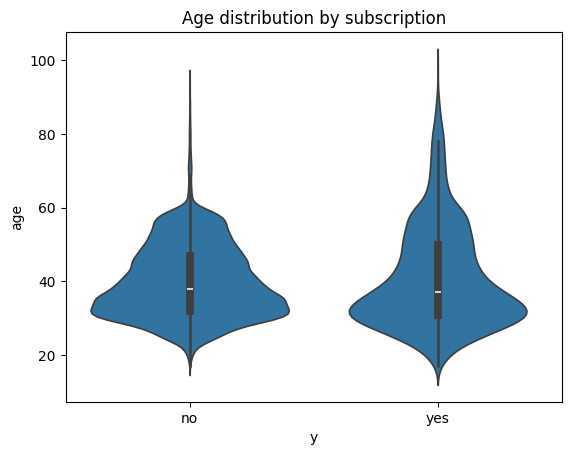

In [9]:
sns.violinplot(data=raw_df, x='y', y='age', inner='box')
plt.title('Age distribution by subscription')
plt.show()

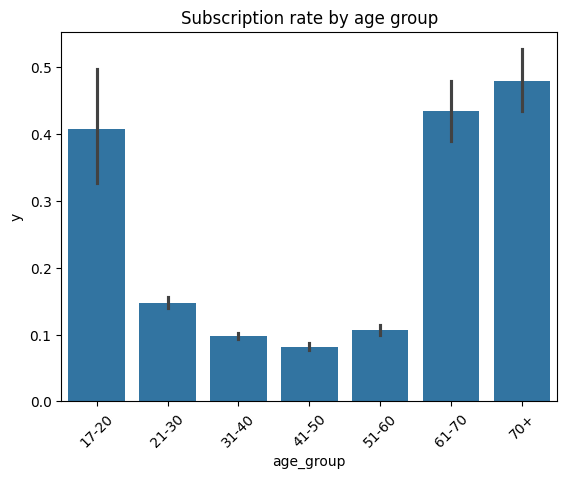

In [10]:
raw_df['age_group'] = pd.cut(raw_df['age'], bins=[17, 20, 30, 40, 50, 60, 70, 100],
              labels = ['17-20', '21-30', '31-40', '41-50', '51-60', '61-70', '70+'])
sns.barplot(data=raw_df, x='age_group', y=(raw_df['y'] == 'yes'))
plt.title('Subscription rate by age group')
plt.xticks(rotation=45)
plt.show()

In [11]:
raw_df['age_group'].value_counts()

,count
age_group,
31-40,16385
41-50,10240
21-30,7243
51-60,6270
61-70,488
70+,422
17-20,135


**Conclusions**

- The age distribution for clients who subscribed "yes" is slightly wider compared to those who did not, indicating greater variability among subscribers

- The majority of clients in the dataset fall into the 26–35 age group, which explains the higher absolute number of both "yes" and "no" outcomes in this segment

- Although older age groups 60+ have fewer observations compared to middle-aged groups, the increase in subscription rate is consistent across multiple adjacent age bins 61–70 and 70+

- This consistency suggests that the observed pattern is likely meaningful rather than random noise.

- In contrast, the 17–20 age group has a very small sample size, making its high subscription rate less reliable

#### Job & y

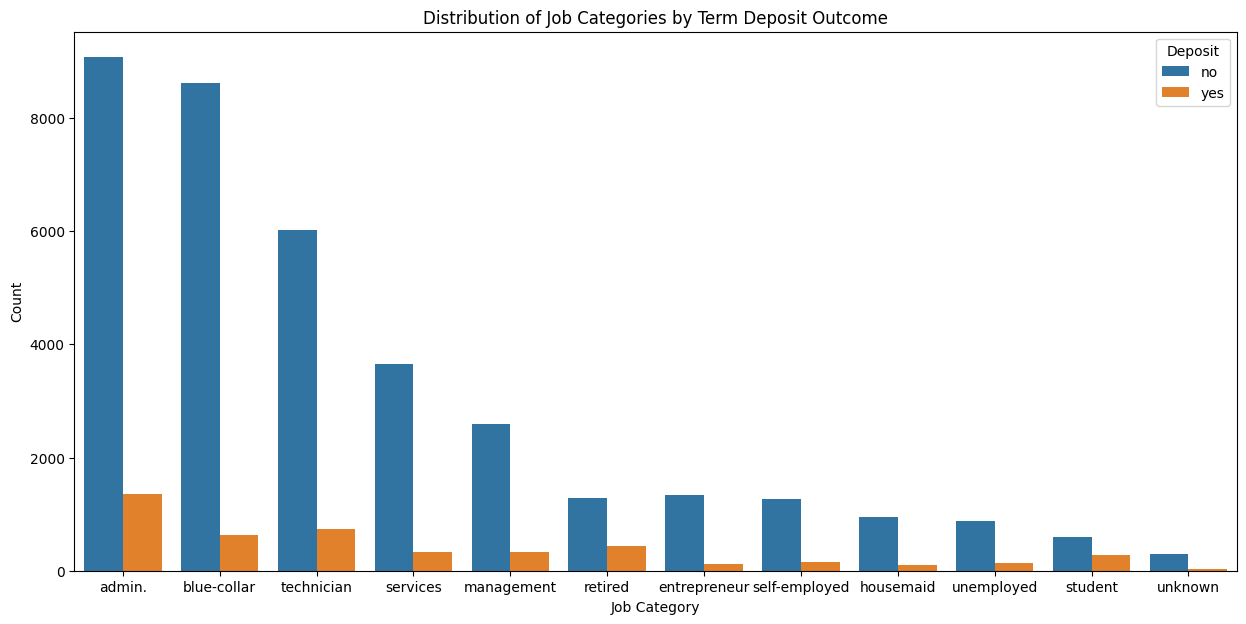

In [12]:
plt.figure(figsize=(15, 7))
sns.countplot(data=raw_df, x='job', hue='y', order = raw_df['job'].value_counts().index)
plt.title('Distribution of Job Categories by Term Deposit Outcome')
plt.ylabel('Count')
plt.xlabel('Job Category')
plt.legend(title='Deposit')
plt.show()

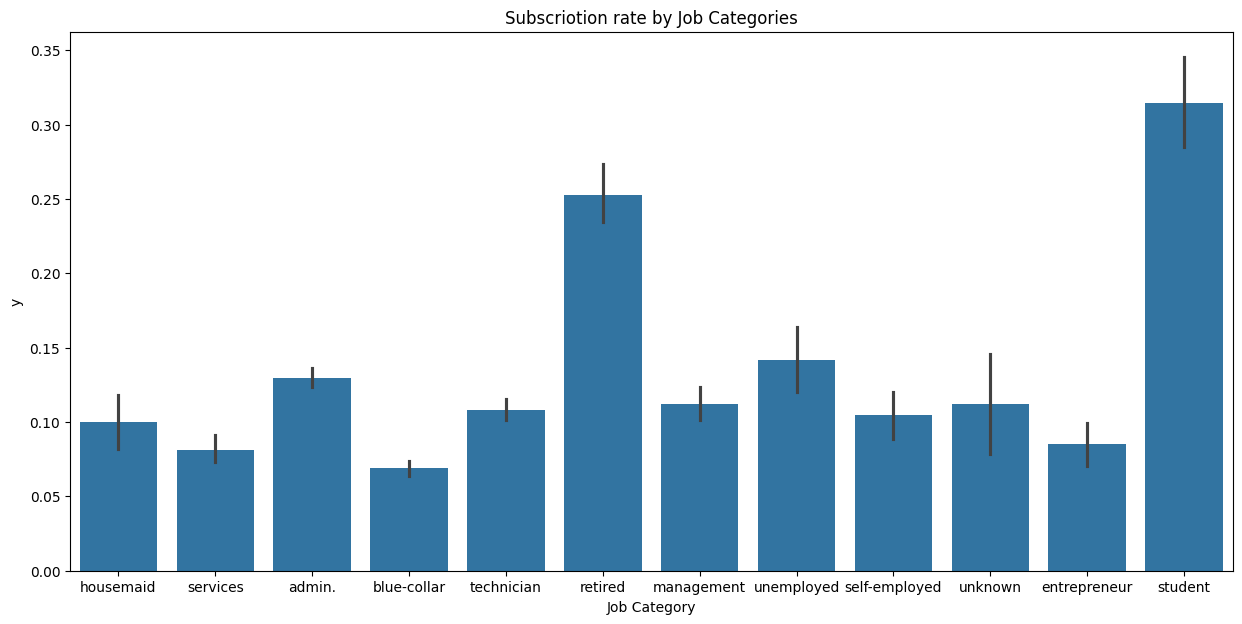

In [13]:
plt.figure(figsize=(15, 7))
sns.barplot(data=raw_df, x='job', y=(raw_df['y'] == 'yes'))
plt.title('Subscriotion rate by Job Categories')
plt.ylabel('y')
plt.xlabel('Job Category')
plt.show()

In [14]:
raw_df.groupby('job')['y'].value_counts(normalize=True).unstack().sort_values(by='yes', ascending=False)

y,no,yes
job,,
student,0.685714,0.314286
retired,0.747674,0.252326
unemployed,0.857988,0.142012
admin.,0.870274,0.129726
management,0.887825,0.112175
unknown,0.887879,0.112121
technician,0.891740,0.108260
self-employed,0.895144,0.104856
housemaid,0.900000,0.100000


**Conclusions**

- The most common job categories in the dataset are admin., blue-collar, and technician, which explains the higher absolute number of subscriptions and non-subscriptions in these groups

- When analyzing subscription rates, clear differences emerge across job categories. Clients in the "student" ~31% and "retired" ~25% categories show the highest likelihood of subscribing to a term deposit

- However, these groups have relatively smaller sample sizes compared to dominant categories (e.g., admin., blue-collar), which should be taken into account when interpreting the results

- The higher subscription rate among retired clients may be explained by a greater focus on savings and financial stability, while students may have fewer financial obligations and be more open to saving products

#### poutcome & y

In [15]:
raw_df.groupby('poutcome')['y'].value_counts(normalize=True).unstack()

y,no,yes
poutcome,,
failure,0.857714,0.142286
nonexistent,0.911678,0.088322
success,0.348871,0.651129


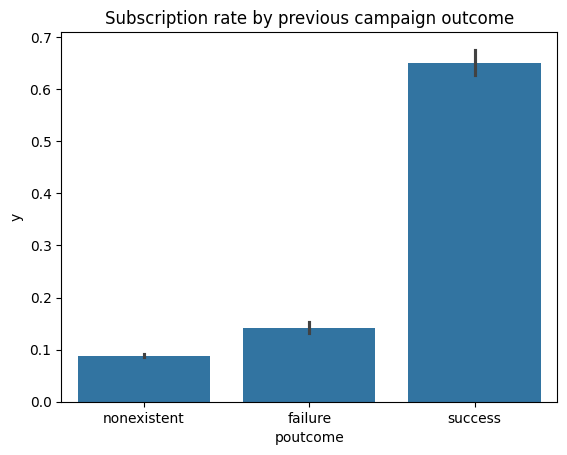

In [16]:
sns.barplot(data=raw_df, x='poutcome', y=(raw_df['y'] == 'yes'))
plt.title('Subscription rate by previous campaign outcome')
plt.show()

In [17]:
raw_df['poutcome'].value_counts()

,count
poutcome,
nonexistent,35563
failure,4252
success,1373


**Conclusions**

- Clients who had a successful outcome in previous marketing campaigns show a significantly higher probability of subscribing to a term deposit 65% compared to those with previous failures 14% or no prior contact 9%

- This indicates that past positive interactions with the bank strongly influence future customer behavior

- Clients with no prior contact "nonexistent" have the lowest subscription rate, suggesting that familiarity with the bank and prior engagement are important drivers of conversion

- Overall, the feature poutcome appears to be one of the most predictive variables in the dataset

#### housing/loan & y

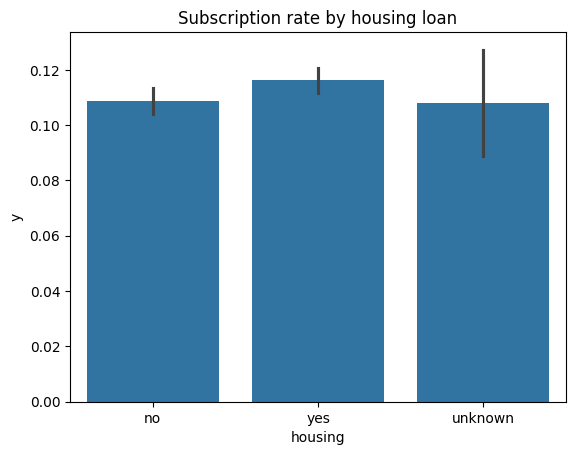

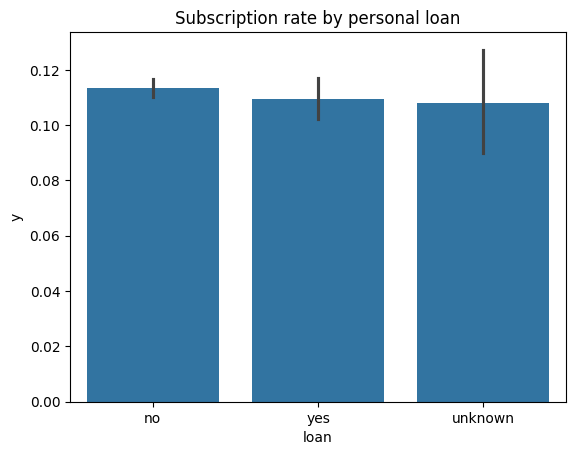

In [18]:
sns.barplot(data=raw_df, x='housing', y=(raw_df['y'] == 'yes'))
plt.title('Subscription rate by housing loan')
plt.show()

sns.barplot(data=raw_df, x='loan', y=(raw_df['y'] == 'yes'))
plt.title('Subscription rate by personal loan')
plt.show()

**Conclusions**

- No significant relationship was observed between having a housing or personal loan and the likelihood of subscribing to a term deposit

- Subscription rates remain relatively stable across all combinations of loan statuses (10–12%).

- Interestingly, clients with housing loans show a slightly higher subscription rate, although the difference is marginal and may not be practically significant

- Overall, loan-related features do not appear to be strong predictors of subscription behavior on their own

#### poutcome/60+ & y

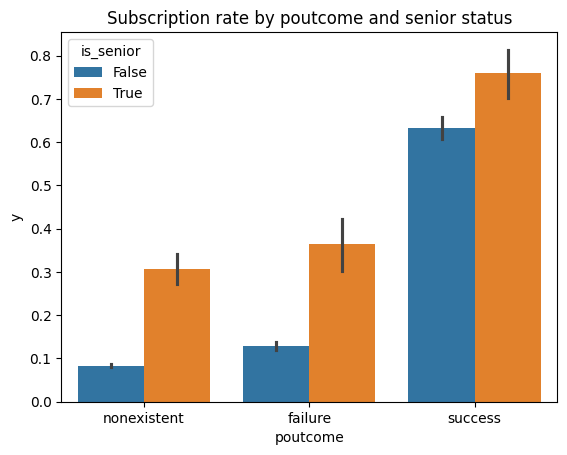

In [19]:
sns.barplot(
    data=raw_df,
    x='poutcome',
    y=(raw_df['y'] == 'yes'),
    hue=raw_df['age'] >= 60
)
plt.title('Subscription rate by poutcome and senior status')
plt.legend(title='is_senior')
plt.show()

**Conclusions**

- An interaction between age and previous campaign success was observed: senior clients with a successful past campaign show the highest subscription rate (~75%)

- To capture this effect, an additional feature combining these two signals was created:

raw_df['senior_and_success'] = (
    (raw_df['poutcome'] == 'success') &
    (raw_df['age'] >= 60))

- This is particularly useful for linear models, which do not automatically capture feature interactions

## Methods and Evaluation Metrics

The task is a binary classification problem aimed at predicting whether a client will subscribe to a term deposit

The following machine learning methods were selected:
- Logistic Regression (as a baseline and interpretable model)
- k-Nearest Neighbors (to capture local patterns)
- Decision Tree (to model non-linear relationships)
- XGBoost (for high predictive performance)

Since the dataset is imbalanced (11% positive class), accuracy is not an appropriate metric. ROC-AUC was chosen as the primary evaluation metric, as it reflects the model’s ability to distinguish between classes across different thresholds. Additionally, F1-score was used to balance precision and recall. Precision and recall will be also monitored to better understand trade-offs in model predictions

## Data Preprocessing

Since no missing values were found in the dataset, no imputation was required

The following preprocessing steps were applied:
- the target variable y was converted to binary format
- the feature duration was removed due to data leakage
- created additional features were created based on EDA

Preprocessing strategies were used depending on the model type:

For Logistic Regression and kNN categorical variables were one-hot encoded, numerical variables were scaled, extreme values in campaign variable were capped

For Desicion tree model categorical variables were one-hot encoded, numerical variables were kept in the original scale

For XGBoost categorical features were converted to pandas category dtype, the model was trained using enable_categorical=True

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

In [21]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bank-additional-full.csv', delimiter=';')

# target
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# feature engineering
df['is_senior'] = (df['age'] >= 60).astype(int)
df['was_success_before'] = (df['poutcome'] == 'success').astype(int)
df['senior_and_success'] = (df['is_senior'] & df['was_success_before']).astype(int)

# remove leakage feature
df = df.drop(columns=['duration'])

In [22]:
X = df.drop(columns=['y'])
y = df['y']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
categorical_features = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

numeric_features = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

binary_features = [
    'is_senior', 'was_success_before', 'senior_and_success'
]

In [24]:
def clip_campaign(X):
    X = X.copy()
    X['campaign'] = X['campaign'].clip(upper=10)
    return X

In [25]:
#preprocessing for LR & kNN
preprocessor_lr_knn = Pipeline(steps=[
    ('clip_campaign', FunctionTransformer(clip_campaign)),
    ('transform', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('bin', 'passthrough', binary_features)
        ]
    ))
])

In [26]:
#preprocessing for Decision Tree
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

In [27]:
#preprocessing for XGBoost
X_train_xgb = X_train.copy()
X_valid_xgb = X_valid.copy()

for col in categorical_features:
    X_train_xgb[col] = X_train_xgb[col].astype('category')
    X_valid_xgb[col] = X_valid_xgb[col].astype('category')

In [28]:
# metrics
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

def evaluate_model(model, X_train, y_train, X_valid, y_valid,
                   model_name='model', threshold=0.5):
    # probabilities
    train_proba = model.predict_proba(X_train)[:, 1]
    valid_proba = model.predict_proba(X_valid)[:, 1]

    # custom threshold
    train_pred = (train_proba >= threshold).astype(int)
    valid_pred = (valid_proba >= threshold).astype(int)

    results = {
        'model': model_name,
        'threshold': threshold,

        'train_roc_auc': roc_auc_score(y_train, train_proba),
        'valid_roc_auc': roc_auc_score(y_valid, valid_proba),

        'train_f1': f1_score(y_train, train_pred, zero_division=0),
        'valid_f1': f1_score(y_valid, valid_pred, zero_division=0),

        'train_precision': precision_score(y_train, train_pred, zero_division=0),
        'valid_precision': precision_score(y_valid, valid_pred, zero_division=0),

        'train_recall': recall_score(y_train, train_pred, zero_division=0),
        'valid_recall': recall_score(y_valid, valid_pred, zero_division=0),

        'train_accuracy': accuracy_score(y_train, train_pred),
        'valid_accuracy': accuracy_score(y_valid, valid_pred),
    }

    return pd.DataFrame([results]).round(3)

## LR

In [29]:
from sklearn.linear_model import LogisticRegression

lr = Pipeline(steps=[
    ('preprocessor', preprocessor_lr_knn),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

In [30]:
lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('clip_campaign',
                                  FunctionTransformer(func=<function clip_campaign at 0x7de4ece3fce0>)),
                                 ('transform',
                                  ColumnTransformer(transformers=[('num',
                                                                   StandardScaler(),
                                                                   ['age',
                                                                    'campaign',
                                                                    'pdays',
                                                                    'previous',
                                                                    'emp.var.rate',
                                                                    'cons.price.idx',
                                                                    'cons.conf.idx',
                                                                    'euribor3m',
                                                                    'nr.employed']),
                                                                  ('cat',
                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                   ['job',
                                                                    'marital',
                                                                    'education',
                                                                    'default',
                                                                    'housing',
                                                                    'loan',
                                                                    'contact',
                                                                    'month',
                                                                    'day_of_week',
                                                                    'poutcome']),
                                                                  ('bin',
                                                                   'passthrough',
                                                                   ['is_senior',
                                                                    'was_success_before',
                                                                    'senior_and_success'])]))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [31]:
evaluate_model(lr, X_train, y_train, X_valid, y_valid, model_name='LR', threshold = 0.5)

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,LR,0.5,0.795,0.801,0.452,0.469,0.354,0.367,0.626,0.648,0.829,0.835


**Conclusions**

The Logistic Regression model demonstrates good discriminative ability, ROC-AUC 0.801 on validation data

The model achieves relatively high recall 0.648, meaning it successfully identifies a large portion of clients who subscribe to a term deposit. However, precision remains relatively low 0.367, indicating a considerable number of false positives

Overall, the model is suitable as a baseline

In [32]:
lr_results_table = pd.DataFrame({
    'model': 'Logistic Regression',

    'hyperparameters': [
        'class_weight=balanced, max_iter=1000'
    ],

    'train_roc_auc': 0.795,
    'valid_roc_auc': 0.801,

    'train_f1': 0.452,
    'valid_f1': 0.469,

    'comment': [
        'Good baseline model with stable performance ROC-AUC 0.801 on validation.'
        'Shows balanced performance with moderate F1-score. '
        'Can be improved with threshold tuning and feature engineering'
    ]
})

## KNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline(steps=[
    ('preprocessor', preprocessor_lr_knn),
    ('model', KNeighborsClassifier(n_neighbors=6))
])

In [34]:
knn.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('clip_campaign',
                                  FunctionTransformer(func=<function clip_campaign at 0x7de4ece3fce0>)),
                                 ('transform',
                                  ColumnTransformer(transformers=[('num',
                                                                   StandardScaler(),
                                                                   ['age',
                                                                    'campaign',
                                                                    'pdays',
                                                                    'previous',
                                                                    'emp.var.rate',
                                                                    'cons.price.idx',
                                                                    'cons.conf.idx',
                                                                    'euribor3m',
                                                                    'nr.employed']),
                                                                  ('cat',
                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                   ['job',
                                                                    'marital',
                                                                    'education',
                                                                    'default',
                                                                    'housing',
                                                                    'loan',
                                                                    'contact',
                                                                    'month',
                                                                    'day_of_week',
                                                                    'poutcome']),
                                                                  ('bin',
                                                                   'passthrough',
                                                                   ['is_senior',
                                                                    'was_success_before',
                                                                    'senior_and_success'])]))])),
                ('model', KNeighborsClassifier(n_neighbors=6))])

In [35]:
evaluate_model(knn, X_train, y_train, X_valid, y_valid, model_name='kNN')

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,kNN,0.5,0.916,0.755,0.523,0.437,0.632,0.538,0.446,0.369,0.908,0.893


**Conclusions**

 - The kNN model demonstrates strong performance on the training set ROC-AUC 0.916, but significantly lower performance on the validation set ROC-AUC 0.755, indicating overfitting

 - Compared to Logistic Regression, kNN achieves higher precision 0.538, meaning it produces fewer false positive predictions. However, recall is considerably lower 0.369, which means the model fails to identify a large portion of potential subscribers

 - The model underperforms compared to Logistic Regression in terms of overall balance F1-score 0.437 vs 0.469 and generalization

 - Possible improvements include tuning n_neighbors, experimenting with distance metrics, using distance-based weighting, and applying resampling techniques to address class imbalance

In [36]:
knn_results_table = pd.DataFrame({
    'model': 'kNN',
    'hyperparameters': 'n_neighbors=6',
    'train_roc_auc': 0.916,
    'valid_roc_auc': 0.755,
    'train_f1': 0.523,
    'valid_f1': 0.437,
    'comment': [
        'Shows overfitting and lower performance than LR, higher precision but low recall. '
        'Possible improvements include tuning hyperparameters '
        'and applying resampling techniques to address class imbalance'
    ]
})


## Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

tree = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    ))
])

In [38]:
tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome']),
                                                 ('bin', 'passthrough',
                                                  ['is_senior',
                                                   'was_success_before',
                                                   'senior_and_success'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [39]:
evaluate_model(tree, X_train, y_train, X_valid, y_valid, model_name='tree')

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,tree,0.5,0.788,0.796,0.469,0.481,0.386,0.396,0.599,0.612,0.847,0.851


**Conclusions**

 - The Decision Tree model shows stable performance, with very similar results on the training and validation sets, indicating little to no overfitting

 - ROC-AUC on validation 0.796 is close to Logistic Regression model, while the validation F1-score 0.481 is slightly higher. Compared to kNN, the model generalizes better and achieves stronger validation performance

 - Precision remains moderate 0.396, meaning that the model still produces a considerable number of false positive predictions. However, recall is relatively high 0.612, indicating that the model successfully identifies most clients who subscribe to a term deposit

 - Overall, this Decision Tree provides a good balance between interpretability and predictive performance, making it a strong candidate for further experiments

In [40]:
tree_results_table = pd.DataFrame({
    'model': ['Decision Tree'],
    'hyperparameters': ['max_depth=5, class_weight=balanced'],
    'train_roc_auc': [0.788],
    'valid_roc_auc': [0.796],
    'train_f1': [0.469],
    'valid_f1': [0.481],
    'comment': [
        'Stable model with no clear overfitting, slightly better F1 than LR and stronger generalization than kNN. '
        'Possible improvements include tuning tree hyperparameters, adding new features'
    ]
})

## XGBoost base

In [41]:
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    enable_categorical=True
)

In [42]:
xgb_base.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [43]:
evaluate_model(xgb_base, X_train_xgb, y_train, X_valid_xgb, y_valid, model_name='xgb_base')

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,xgb_base,0.5,0.869,0.811,0.486,0.395,0.809,0.661,0.348,0.281,0.917,0.903


**Conclusions**

- The baseline XGBoost model achieved the highest validation ROC-AUC 0.811 among all tested models, indicating the strongest ability to distinguish between clients who subscribe and those who do not

- There is a gap between training and validation performance: ROC-AUC 0.869 on train vs 0.811 on validation and F1 0.486 on train vs 0.395 on validation, suggesting moderate overfitting

 - At the default threshold of 0.5, the model shows very high precision 0.661, meaning that positive predictions are often correct. However, recall is quite low 0.281, which indicates that the model misses a large share of actual subscribers. As a result, the F1-score is lower than that of Logistic Regression and Decision Tree, despite the high ROC-AUC

- Overall, the baseline XGBoost model is a strong candidate for further improvement. The next steps include hyperparameter tuning and threshold adjustment to achieve a better balance between precision and recall

In [44]:
xgb_base_results_table = pd.DataFrame({
    'model': 'XGBoost base',
    'hyperparameters':
        'n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8'
    ,
    'train_roc_auc': 0.869,
    'valid_roc_auc': 0.811,
    'train_f1': 0.486,
    'valid_f1': 0.395,
    'comment': [
        'Best ROC-AUC so far, but at threshold 0.5 the model is too conservative: high precision and low recall. '
        'Possible improvements include threshold and hyperparameter tuning'
    ]
})

## XGBoost & RandomizedSearchCV

In [45]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgb_rs = XGBClassifier(
    random_state=42,
    eval_metric='auc',
    enable_categorical=True
)

space = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5, 1]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_rs,
    param_distributions=space,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_xgb, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5, 1],
                                        'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.2],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [46]:
evaluate_model(random_search, X_train_xgb, y_train, X_valid_xgb, y_valid, model_name='XGBoost random_search')

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,XGBoost random_search,0.5,0.82,0.815,0.356,0.33,0.739,0.704,0.234,0.216,0.904,0.901


**Conclusions**

- Hyperparameter tuning with RandomizedSearchCV slightly improved ROC-AUC (from 0.811 to 0.815)

- However, at the default threshold of 0.5, the model became more conservative: precision increased, while recall decreased significantly, resulting in a lower F1-score 0.33

- This behavior is expected, as the model was optimized for ROC-AUC, which focuses on ranking quality rather than classification performance at a fixed threshold

 - I will try threshold tuning to find better balance between precision and recall

In [47]:
thresholds = [0.2, 0.3, 0.4, 0.5]

results = []

for t in thresholds:
    res = evaluate_model(
        random_search,
        X_train_xgb, y_train,
        X_valid_xgb, y_valid,
        model_name='XGB random',
        threshold=t
    )
    results.append(res)

pd.concat(results)

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,XGB random,0.2,0.82,0.815,0.509,0.526,0.452,0.469,0.582,0.599,0.873,0.878
0,XGB random,0.3,0.82,0.815,0.518,0.517,0.515,0.517,0.521,0.518,0.891,0.891
0,XGB random,0.4,0.82,0.815,0.447,0.431,0.653,0.637,0.340,0.325,0.905,0.903
0,XGB random,0.5,0.82,0.815,0.356,0.330,0.739,0.704,0.234,0.216,0.904,0.901


**Conclusions**

 - Different classification thresholds were evaluated. Lowering the threshold significantly improved model performance

 - At threshold = 0.2, the model achieved the best F1-score 0.526, with a much better balance between precision 0.469 and recall 0.599

In [48]:
params_str = ', '.join([f"{k}={v}" for k, v in random_search.best_params_.items()]) + ', threshold=0.2'

xgb_random_tuned_results_table = pd.DataFrame({
    'model': 'XGBoost Randomized Search + threshold',

    'hyperparameters': params_str,

    'train_roc_auc': 0.82,
    'valid_roc_auc': 0.815,

    'train_f1': 0.509,
    'valid_f1': 0.526,

    'comment': [
        'Strong overall model. Hyperparameter tuning improved ROC-AUC, and threshold adjustment 0.2 significantly improved F1 by balancing precision 0.469 and recall 0.599. '
        'Demonstrates strong performance and good generalization'
    ]
})

## XGBoost & Hyperopt

In [49]:
from hyperopt import hp

space = {
    'n_estimators': hp.choice('n_estimators', [100, 200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 7]),
    'learning_rate': hp.quniform('learning_rate', 0.01, 0.20, 0.01),
    'subsample': hp.quniform('subsample', 0.6, 1.0, 0.1),
    'colsample_bytree': hp.quniform('colsample_bytree', 0.6, 1.0, 0.1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 7, 1),
    'gamma': hp.quniform('gamma', 0.0, 1.0, 0.1),
}

In [50]:
from hyperopt import STATUS_OK
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective(params):
    params = params.copy()

    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model = XGBClassifier(
        random_state=42,
        eval_metric='auc',
        enable_categorical=True,
        **params
    )

    score = cross_val_score(
        model,
        X_train_xgb,
        y_train,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1
    ).mean()

    return {
        'loss': -score,
        'status': STATUS_OK
    }

In [51]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(42)
)

100%|██████████| 30/30 [01:00<00:00,  2.01s/trial, best loss: -0.7987343851204308]


In [52]:
best_params = {
    'n_estimators': [100, 200, 300, 400, 500][best['n_estimators']],
    'max_depth': [3, 4, 5, 6, 7][best['max_depth']],
    'learning_rate': float(best['learning_rate']),
    'subsample': float(best['subsample']),
    'colsample_bytree': float(best['colsample_bytree']),
    'min_child_weight': int(best['min_child_weight']),
    'gamma': float(best['gamma'])
}

best_params

{'n_estimators': 200,
 'max_depth': 6,
 'learning_rate': 0.02,
 'subsample': 0.7000000000000001,
 'colsample_bytree': 0.6000000000000001,
 'min_child_weight': 6,
 'gamma': 0.6000000000000001}

In [53]:
xgb_hopt = XGBClassifier(
    random_state=42,
    eval_metric='auc',
    enable_categorical=True,
    **best_params
)

xgb_hopt.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6000000000000001, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.6000000000000001, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=6, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [54]:
evaluate_model(xgb_hopt, X_train_xgb, y_train,X_valid_xgb, y_valid, model_name='XGBoost Hyperopt')

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,XGBoost Hyperopt,0.5,0.835,0.816,0.4,0.362,0.742,0.698,0.273,0.245,0.907,0.903


**Conclusions**

- Hyperopt was used to further tune XGBoost hyperparameters. This model slightly improved ROC-AUC 0.816, achieving the best ranking performance among all models

- However, similar to Randomized Search, the model became more conservative at the default threshold 0.5, resulting in high precision but low recall and F1-score

- I will try threshold tuning to achieve a better balance between precision and recall

In [55]:
thresholds = [0.2, 0.3, 0.4, 0.5]

results = []

for t in thresholds:
    res = evaluate_model(
        xgb_hopt,
        X_train_xgb, y_train,
        X_valid_xgb, y_valid,
        model_name='XGBoost Hyperopt',
        threshold=t
    )
    results.append(res)

pd.concat(results)

,model,threshold,train_roc_auc,valid_roc_auc,train_f1,valid_f1,train_precision,valid_precision,train_recall,valid_recall,train_accuracy,valid_accuracy
0,XGBoost Hyperopt,0.2,0.835,0.816,0.512,0.531,0.455,0.473,0.586,0.606,0.874,0.880
0,XGBoost Hyperopt,0.3,0.835,0.816,0.531,0.520,0.532,0.519,0.530,0.520,0.895,0.892
0,XGBoost Hyperopt,0.4,0.835,0.816,0.484,0.457,0.660,0.617,0.383,0.363,0.908,0.903
0,XGBoost Hyperopt,0.5,0.835,0.816,0.400,0.362,0.742,0.698,0.273,0.245,0.907,0.903


**Conslusions**

- After threshold tuning, the optimal threshold was found to be 0.2, resulting in the best F1-score 0.531 and a good balance between precision 0.473 and recall 0.606

- Interestingly, both Randomized Search and Hyperopt produced very similar final performance, suggesting that the choice of tuning method had less impact than proper threshold selection


In [56]:
params_hopt = ', '.join([f"{k}={round(v, 3) if isinstance(v, float) else v}"
    for k, v in sorted(best_params.items())]) +', threshold=0.2'

xgb_hopt_results_table = pd.DataFrame({
    'model': 'XGBoost Hyperopt + threshold',

    'hyperparameters': params_hopt,

    'train_roc_auc': 0.835,
    'valid_roc_auc': 0.816,

    'train_f1': 0.512,
    'valid_f1': 0.531,

    'comment': [
        'Best performing model. Hyperopt slightly improved ROC-AUC, and threshold tuning 0.2 achieved the highest F1 with a good precision-recall balance. '
        'Performance is similar to Randomized Search, confirming that threshold selection has a larger impact than tuning method'
    ]
})

## Model comparison table

In [67]:
result_table = pd.concat([lr_results_table, knn_results_table, \
    tree_results_table, xgb_base_results_table, xgb_random_tuned_results_table,
    xgb_hopt_results_table], ignore_index=True)
result_table

,model,hyperparameters,train_roc_auc,valid_roc_auc,train_f1,valid_f1,comment
0,Logistic Regression,"class_weight=balanced, max_iter=1000",0.795,0.801,0.452,0.469,Good baseline model with stable performance RO...
1,kNN,n_neighbors=6,0.916,0.755,0.523,0.437,Shows overfitting and lower performance than L...
2,Decision Tree,"max_depth=5, class_weight=balanced",0.788,0.796,0.469,0.481,"Stable model with no clear overfitting, slight..."
3,XGBoost base,"n_estimators=300, max_depth=5, learning_rate=0...",0.869,0.811,0.486,0.395,"Best ROC-AUC so far, but at threshold 0.5 the ..."
4,XGBoost Randomized Search + threshold,"subsample=0.9, n_estimators=300, min_child_wei...",0.820,0.815,0.509,0.526,Strong overall model. Hyperparameter tuning im...
5,XGBoost Hyperopt + threshold,"colsample_bytree=0.6, gamma=0.6, learning_rate...",0.835,0.816,0.512,0.531,Best performing model. Hyperopt slightly impro...


## Feature importance XGBoost hopt

In [58]:
feature_importance = pd.DataFrame({
    'feature': X_train_xgb.columns,
    'importance': xgb_hopt.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(10)

,feature,importance
18,nr.employed,0.553543
11,pdays,0.070112
20,was_success_before,0.060512
14,emp.var.rate,0.051401
16,cons.conf.idx,0.032292
8,month,0.031329
17,euribor3m,0.027606
13,poutcome,0.025651
7,contact,0.023647
15,cons.price.idx,0.018031


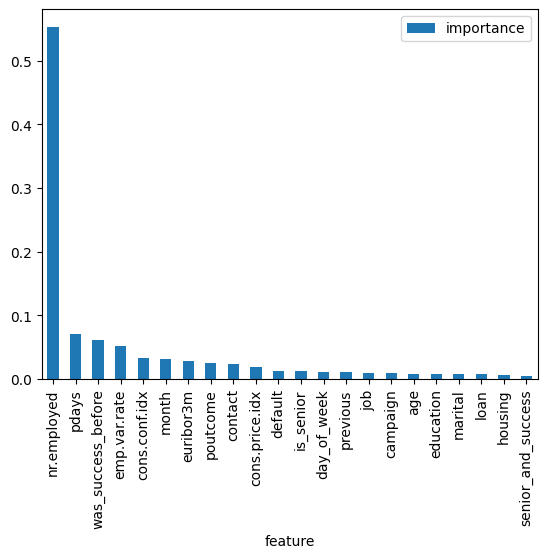

In [59]:
import matplotlib.pyplot as plt

feature_importance.set_index('feature').plot.bar();

**Conclusions**


The most important features in the model are:

1. nr.employed - number of employed people in the economy. This reflects overall economic conditions, which can affect how people make financial decisions

2. pdays - number of days since the last contact. This captures how recently the client was contacted, which is important in marketing

3. was_success_before - whether the client subscribed in a previous campaign.  This is a very strong predictor, which makes sense: clients who agreed before are more likely to agree again

4. emp.var.rate - employment change rate. This shows how the economy is changing and can influence customer confidence

5. cons.conf.idx - represents the Consumer Confidence Index, which reflects how optimistic people feel about the economy

Overall, the results make sense. Both economic factors and previous customer behavior play a key role in predicting whether a client will subscribe

## SHAP


In [60]:
import shap

explainer = shap.TreeExplainer(xgb_hopt)
shap_values = explainer.shap_values(X_valid_xgb)

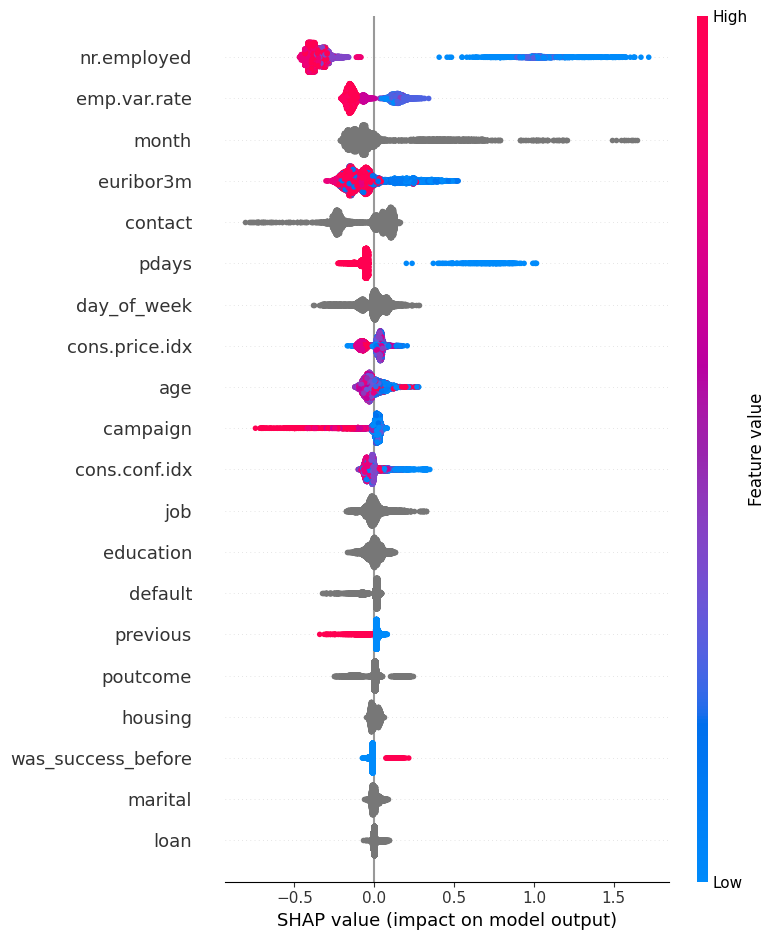

In [61]:
shap.summary_plot(shap_values, X_valid_xgb)

**Conclusions**

SHAP analysis was used to understand how the most important features influence model predictions

- nr.employed has the strongest impact on the model. Lower values tend to increase the probability of subscription, while higher values decrease it. This suggests that economic conditions play a major role in customer decisions

- emp.var.rate also has a strong influence.  Changes in employment rate affect predictions, indicating that the model captures broader economic trends

- month - some months are more effective for marketing than others

- euribor3m - lower interest rates tend to increase the probability of subscription, which aligns with how financial products behave in different market conditions

- pdays - days since last contact. This suggests that recency of interaction is important, clients contacted more recently behave differently

Overall, the SHAP results are consistent with expectations. The model mainly relies on macroeconomic conditions, timing of the campaign and previous interaction history

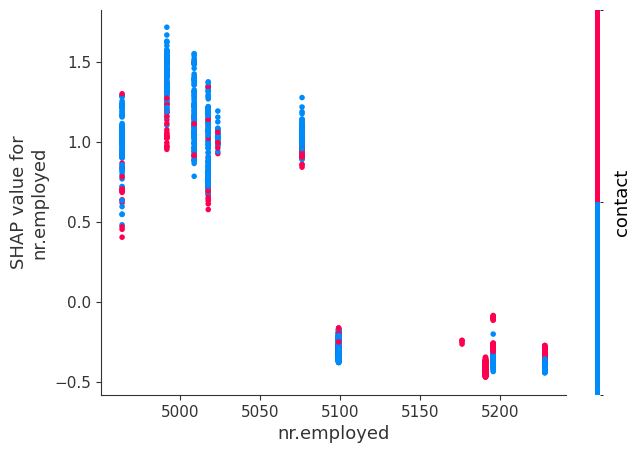

In [62]:
shap.dependence_plot('nr.employed', shap_values, X_valid_xgb)

The dependence plot for nr.employed shows a clear pattern: lower values of this feature increase the predicted probability of subscription, while higher values decrease it

## Error research

In [63]:
y_proba = xgb_hopt.predict_proba(X_valid_xgb)[:, 1]
y_pred = (y_proba >= 0.2).astype(int)

# positions
fp_positions = np.where((y_pred == 1) & (y_valid.values == 0))[0]
fn_positions = np.where((y_pred == 0) & (y_valid.values == 1))[0]

shap.initjs()

pos = fn_positions[0]

print("True label:", y_valid.iloc[pos])
print("Predicted probability:", y_proba[pos])
print("Predicted class:", y_pred[pos])

shap.force_plot(
    explainer.expected_value,
    shap_values[pos, :],
    X_valid_xgb.iloc[pos, :]
)

True label: 1
Predicted probability: 0.04841928
Predicted class: 0


**Conclusions**

False Negative example

True label: Yes, predicted probability: 0.048, predicted label: No  

In this case, the model made a confident mistake, assigning a very low probability to a client who actually subscribed. Main drivers of the error was strong negative signals came from:
  - nr.employed - high value
  - campaign = 8 - many contact attempts
  - emp.var.rate - positive value
  - euribor3m - high interest rate
  - pdays = 999 - no recent contact

These features pushed the prediction strongly toward "no"

Positive signals (contact = cellular, cons.price.idx) were present but much weaker and could not offset the dominant negative factors

The model relies heavily on macroeconomic conditions and campaign-related features. When these signals are negative, they can overpower individual-level indicators, leading to missed true positive cases

We can improve model, for example, add more customer-level or behavioral features to better capture individual intent, reduce over-reliance on macroeconomic variables  

In [64]:
shap.initjs()

pos = fp_positions[0]

print("True label:", y_valid.iloc[pos])
print("Predicted probability:", y_proba[pos])
print("Predicted class:", y_pred[pos])

shap.force_plot(
    explainer.expected_value,
    shap_values[pos, :],
    X_valid_xgb.iloc[pos, :]
)

True label: 0
Predicted probability: 0.32190344
Predicted class: 1


**Conclusions**

False Positive example

True label: No, Predicted probability: 0.32, Predicted label: Yes  

In this case, the model predicted a positive outcome, although the client did not subscribe.Main drivers of strong positive signals came from:
  - emp.var.rate = -2.9
  - euribor3m - low value
  - nr.employed - favorable value
  - contact = cellular
  - housing = no

These features pushed the prediction toward "yes"

Negative signals pdays = 999 or age were weaker and did not sufficiently counterbalance the positive signals

The model is strongly influenced by favorable macroeconomic conditions. It tends to assume that in a good economic environment, clients are more likely to subscribe, even if individual behavior does not fully support this

Ways to improve model: add interaction features to better capture customer-specific behavior, improve calibration of the model to avoid overconfidence